# Stat 153/248 - Lecture 16

Here we will have some demos of autoregression.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

plt.rcParams.update({
    'figure.figsize': (12, 4),
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
})

rng = np.random.default_rng(42)

Let's look at some example time series below. Which of these seems to have "memory" (i.e. where $x_t$ depends on its past values?)

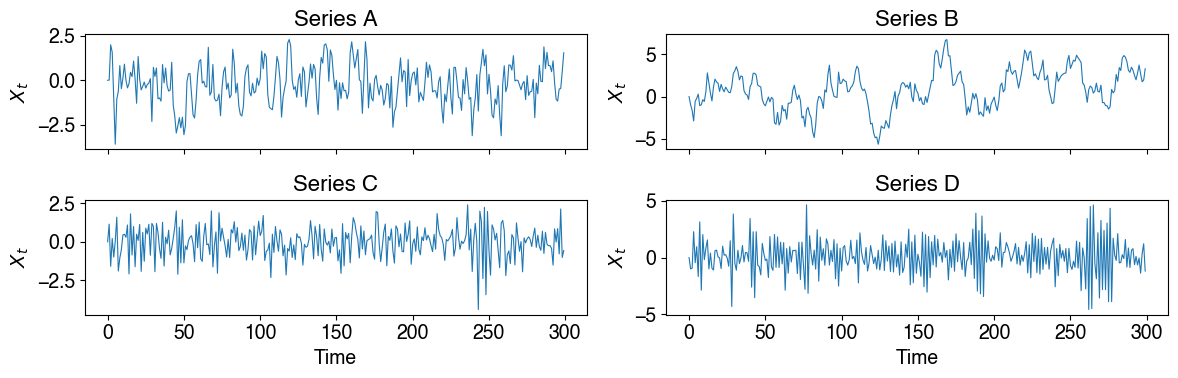

In [6]:
n = 300

# A
#series_a = rng.standard_normal(n)
series_a = np.zeros(n)
for t in range(1, n):
    series_a[t] = 0.5 * series_a[t-1] + rng.standard_normal()


# B: AR(1) with phi = 0.9
series_b = np.zeros(n)
for t in range(1, n):
    series_b[t] = 0.9 * series_b[t-1] + rng.standard_normal()

# C: random walk (unit root)
#series_c = np.cumsum(rng.standard_normal(n))
# D: AR(1) with phi = -0.8 (oscillatory)
series_c = np.zeros(n)
for t in range(1, n):
    series_c[t] = -0.3 * series_c[t-1] + rng.standard_normal()


# D: AR(1) with phi = -0.8 (oscillatory)
series_d = np.zeros(n)
for t in range(1, n):
    series_d[t] = -0.8 * series_d[t-1] + rng.standard_normal()

fig, axes = plt.subplots(2, 2, sharex=True)
for ax, series, label in zip(axes.flat,
                              [series_a, series_b, series_c, series_d],
                              ['Series A', 'Series B', 'Series C', 'Series D']):
    ax.plot(series, lw=0.8)
    ax.set_title(label)
    ax.set_ylabel('$X_t$')
axes[1, 0].set_xlabel('Time')
axes[1, 1].set_xlabel('Time')
plt.tight_layout()
plt.show()

## Simulating different AR(1) models

Let's simulate AR(1) processes with different values of $\phi$ and see what happens. If we increase $\phi$ from 0.5 to 0.95, what do you expect to change about the series?

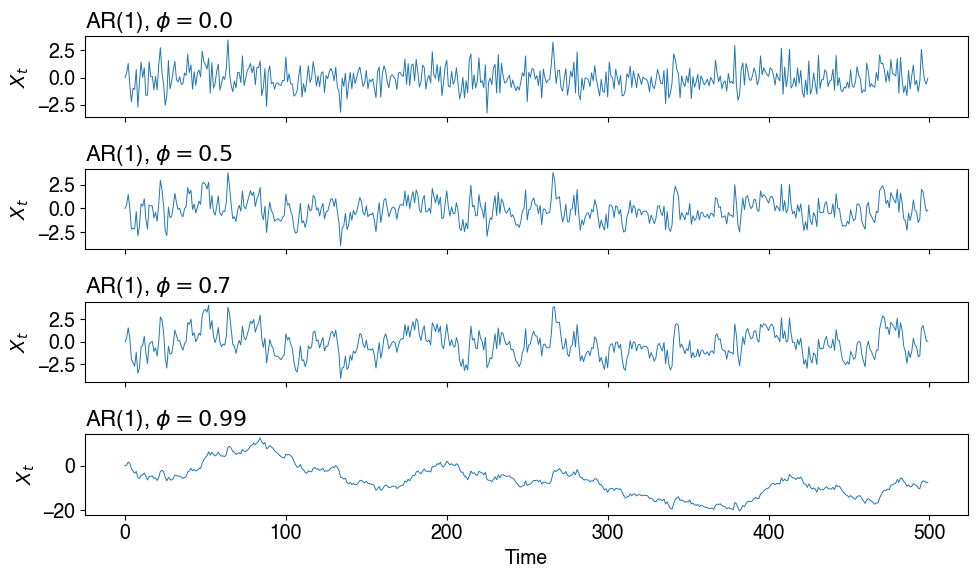

In [13]:
phi_values = [0.0, 0.5, 0.7, 0.99]
n = 500
w = rng.standard_normal(n)  # same shocks for all — isolate effect of phi

fig, axes = plt.subplots(len(phi_values), 1, figsize=(10, 6), sharex=True)

for ax, phi in zip(axes, phi_values):
    x = np.zeros(n)
    for t in range(1, n):
        x[t] = phi * x[t-1] + w[t]
    ax.plot(x, lw=0.7)
    ax.set_title(f'AR(1), $\\phi = {phi}$', loc='left')
    ax.set_ylabel('$X_t$')

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.savefig('images/16_AR1_phi.png')
plt.show()


# Properties of the AR(1) model

Here we will look at how the ACF decays exponentially for a sample AR(1) process, and compare that to the theoretical ACF.

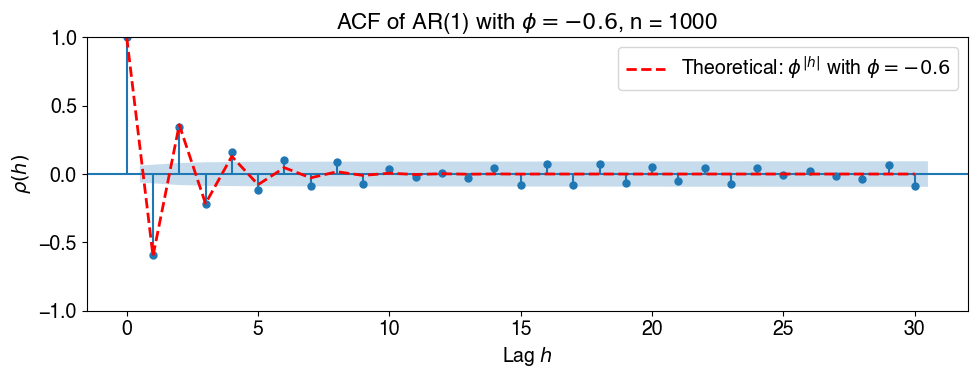

In [19]:
phi = -0.6
n = 1000

# Simulate
x = np.zeros(n)
for t in range(1, n):
    x[t] = phi * x[t-1] + rng.standard_normal()

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(x, lags=30, ax=ax, title='', alpha=0.05)

# Overlay theoretical ACF
lags = np.arange(0, 31)
theoretical_acf = phi ** lags
ax.plot(lags, theoretical_acf, 'r--', lw=2, label=f'Theoretical: $\\phi^{{|h|}}$ with $\\phi={phi}$')
ax.set_title(f'ACF of AR(1) with $\\phi = {phi}$, n = {n}')
ax.set_xlabel('Lag $h$')
ax.set_ylabel('$\\rho(h)$')
ax.legend()
plt.tight_layout()
plt.savefig('images/16_acf.png')
plt.show()

## Example AR(2)

$$x_t = 0.6 x_{t-1} -0.5x_{t-2} + w_t$$

We will do the following:

1. Write the characteristic polynomial
2. Find its roots. Are they real or complex?
3. Is this process stationary?
4. What kind of behavior do you expect?

In [20]:
# Solve the AR(2) characteristic equation ---
phi_1, phi_2 = 0.6, -0.5

# phi(z) = 1 - 0.6z + 0.5z^2
# from highest to lowest p
coeffs = [-phi_2, phi_1, 1]  # 0.5*z^2 - 0.6*z + 1 = 0
roots = np.roots(coeffs)

print(f"Characteristic polynomial: phi(z) = 1 - {phi_1}z + {phi_2}z^2")
print(f"Roots: {roots}")
print(f"Modulus of roots: {np.abs(roots)}")
print(f"All roots outside unit circle? {np.all(np.abs(roots) > 1)}")
print(f"Roots are complex? {np.any(np.iscomplex(roots))}")
print(f"\nIf are complex, we expect oscillatory behavior")
print(f"If |roots| > 1, the process is stationary")

Characteristic polynomial: phi(z) = 1 - 0.6z + -0.5z^2
Roots: [-0.6+1.28062485j -0.6-1.28062485j]
Modulus of roots: [1.41421356 1.41421356]
All roots outside unit circle? True
Roots are complex? True

If are complex, we expect oscillatory behavior
If |roots| > 1, the process is stationary


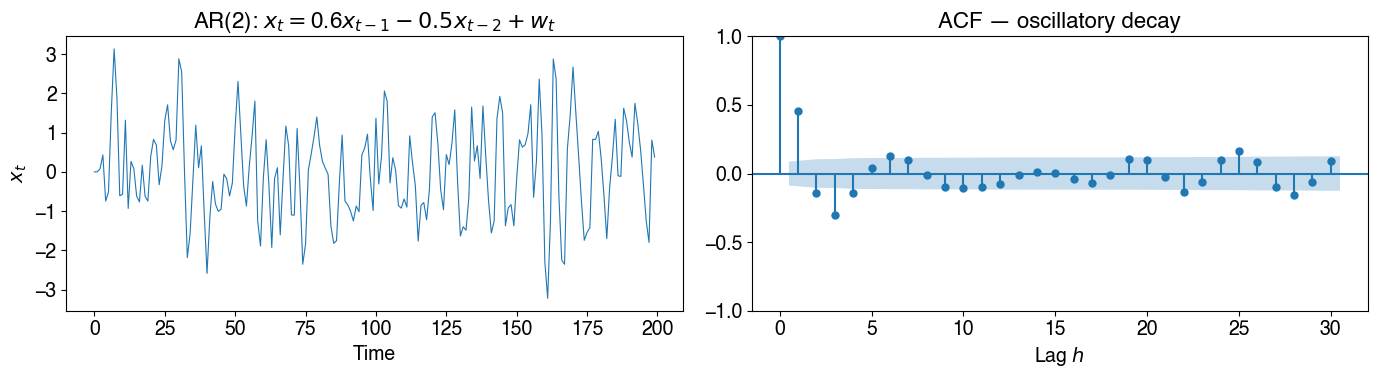

In [21]:
# Let's plot the AR(2) model to verify what we predicted
phi_1, phi_2 = 0.6, -0.5
n = 500

x = np.zeros(n)
for t in range(2, n):
    x[t] = phi_1 * x[t-1] + phi_2 * x[t-2] + rng.standard_normal()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(x[:200], lw=0.8)
axes[0].set_title('AR(2): $x_t = $'+ str(phi_1) + '$x_{t-1} ' + str(phi_2) + 'x_{t-2} + w_t$')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('$x_t$')

plot_acf(x, lags=30, ax=axes[1], title='')
axes[1].set_title('ACF — oscillatory decay')
axes[1].set_xlabel('Lag $h$')

plt.tight_layout()
plt.show()